In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation

2D heat equation solver
Done!


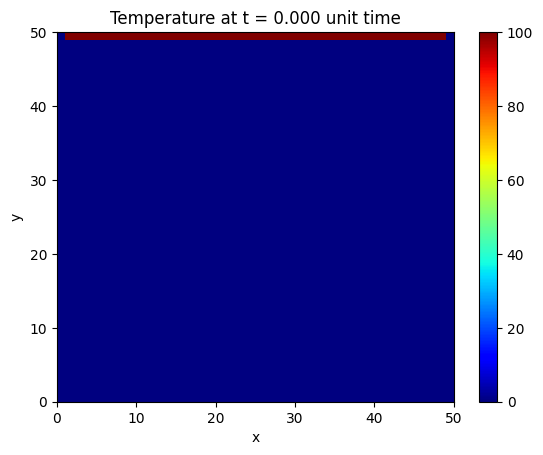

In [23]:
print("2D heat equation solver")

plate_length = 50
max_iter_time = 750

alpha = 2
delta_x = 1

delta_t = (delta_x ** 2)/(4 * alpha)
gamma = (alpha * delta_t) / (delta_x ** 2)

# Initialize solution: the grid of u(k, i, j)
u = np.empty((max_iter_time, plate_length, plate_length))

# Initial condition everywhere inside the grid
u_initial = 0

# Boundary conditions
u_top = 100.0
u_left = 0.0
u_bottom = 0.0
u_right = 0.0

# Set the initial condition
u.fill(u_initial)

# Set the boundary conditions
u[:, (plate_length-1):, :] = u_top
u[:, :, :1] = u_left
u[:, :1, 1:] = u_bottom
u[:, :, (plate_length-1):] = u_right

def calculate(u):
    for k in range(0, max_iter_time-1, 1):
        for i in range(1, plate_length-1, delta_x):
            for j in range(1, plate_length-1, delta_x):
                u[k + 1, i, j] = gamma * (u[k][i+1][j] + u[k][i-1][j] + u[k][i][j+1] + u[k][i][j-1] - 4*u[k][i][j]) + u[k][i][j]

    return u

def plotheatmap(u_k, k):
    # Clear the current plot figure
    plt.clf()

    plt.title(f"Temperature at t = {k*delta_t:.3f} unit time")
    plt.xlabel("x")
    plt.ylabel("y")

    # This is to plot u_k (u at time-step k)
    plt.pcolormesh(u_k, cmap=plt.cm.jet, vmin=0, vmax=100)
    plt.colorbar()

    return plt

# Do the calculation here
u = calculate(u)

def animate(k):
    plotheatmap(u[k], k)

anim = animation.FuncAnimation(plt.figure(), animate, interval=1, frames=max_iter_time, repeat=False)
anim.save("heat_equation_solution.gif", fps=30)

print("Done!")

Simulação concluída! Gerando o GIF...


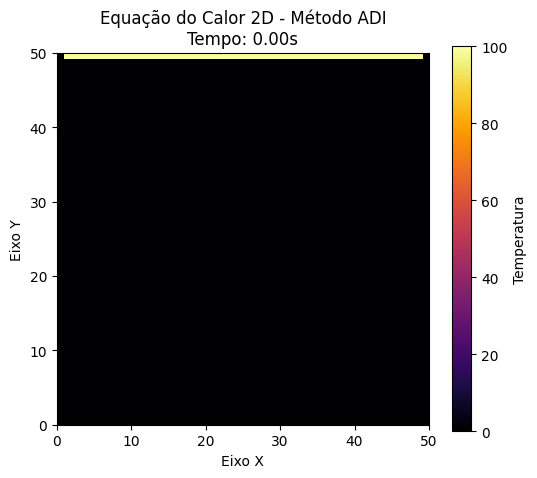

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.linalg import solve_banded

max_iter_time = 100

# ==========================================
# 1. Parâmetros Físicos e da Malha
# ==========================================
Nx = 50   # Número de pontos na malha em x
Ny = 50   # Número de pontos na malha em y
dx = 1
dy = 1

alpha = 2                           # Difusividade térmica
dt = (dx ** 2)/(4 * alpha)     # Passo de tempo (Pode ser grande graças ao ADI!)
Nt = 100                            # Número de passos de tempo

# Constantes do ADI (meio passo de tempo)
rx = alpha * (dt / 2.0) / (dx**2)
ry = alpha * (dt / 2.0) / (dy**2)

# ==========================================
# 2. Condições Iniciais e de Contorno
# ==========================================
# Matriz de temperaturas: u[i, j] onde 'i' é x e 'j' é y
u = np.zeros((Nx, Ny))
u[1:(Nx-1), (Nx-1):] = 100

# Fronteiras de Dirichlet (Mantidas a 0 graus) - já garantido pelo np.zeros nas bordas

# ==========================================
# 3. Preparação das Matrizes Tridiagonais (Algoritmo de Thomas / solve_banded)
# ==========================================
# A função solve_banded do Scipy exige que a matriz esteja em um formato compacto (diagonal)
# Formato: [diagonal superior, diagonal principal, diagonal inferior]

# Matriz para a Varredura X (Implicit em X) - Tamanho (Nx-2)
A_x = np.zeros((3, Nx - 2))
A_x[0, 1:] = -rx           # Diagonal superior
A_x[1, :]  = 1 + 2 * rx    # Diagonal principal
A_x[2, :-1] = -rx          # Diagonal inferior

# Matriz para a Varredura Y (Implicit em Y) - Tamanho (Ny-2)
A_y = np.zeros((3, Ny - 2))
A_y[0, 1:] = -ry           # Diagonal superior
A_y[1, :]  = 1 + 2 * ry    # Diagonal principal
A_y[2, :-1] = -ry          # Diagonal inferior

# ==========================================
# 4. Loop Temporal (Método ADI) e Captura de Frames
# ==========================================
frames = [] # Lista para guardar os dados para o GIF

# Vamos guardar o estado inicial
frames.append(u.copy())

u_half = np.zeros_like(u) # Matriz intermediária para n + 1/2

for n in range(max_iter_time):
    
    # --- PASSO 1: Varredura em X (Implicit em X, Explicit em Y) ---
    # Linha por linha (j varia de 1 a Ny-2)
    for j in range(1, Ny - 1):
        # Lado direito da equação (RHS - explicit em Y) para a linha j
        RHS_x = np.zeros(Nx - 2)
        for i in range(1, Nx - 1):
            RHS_x[i-1] = ry * u[i, j-1] + (1 - 2*ry) * u[i, j] + ry * u[i, j+1]
        
        # Adiciona condições de contorno (X=0 e X=L) ao RHS
        RHS_x[0] += rx * u[0, j]
        RHS_x[-1] += rx * u[-1, j]
        
        # Resolve o sistema tridiagonal e guarda no meio-tempo
        u_half[1:-1, j] = solve_banded((1, 1), A_x, RHS_x)
        
    # Atualiza as bordas de u_half (só por segurança, pois já são 0)
    u_half[0, :] = u[0, :]
    u_half[-1, :] = u[-1, :]
    u_half[:, 0] = u[:, 0]
    u_half[:, -1] = u[:, -1]


    # --- PASSO 2: Varredura em Y (Explicit em X, Implicit em Y) ---
    # Coluna por coluna (i varia de 1 a Nx-2)
    for i in range(1, Nx - 1):
        # Lado direito da equação (RHS - explicit em X) para a coluna i
        RHS_y = np.zeros(Ny - 2)
        for j in range(1, Ny - 1):
            RHS_y[j-1] = rx * u_half[i-1, j] + (1 - 2*rx) * u_half[i, j] + rx * u_half[i+1, j]
            
        # Adiciona condições de contorno (Y=0 e Y=L) ao RHS
        RHS_y[0] += ry * u_half[i, 0]
        RHS_y[-1] += ry * u_half[i, -1]
        
        # Resolve o sistema tridiagonal e guarda no novo tempo u
        u[i, 1:-1] = solve_banded((1, 1), A_y, RHS_y)

    # Armazena a matriz a cada passo de tempo para o GIF
    frames.append(u.copy())

# ==========================================
# 5. Gerando a Animação e Salvando o GIF
# ==========================================
print("Simulação concluída! Gerando o GIF...")

fig, ax = plt.subplots(figsize=(6, 5))
# Transpomos (frames[0].T) para que X fique no eixo horizontal do plot
cax = ax.imshow(frames[0].T, cmap='inferno', origin='lower', extent=[0, Nx, 0, Ny], vmin=0, vmax=100)
ax.set_title("Equação do Calor 2D - Método ADI\nTempo: 0.00s")
ax.set_xlabel("Eixo X")
ax.set_ylabel("Eixo Y")
fig.colorbar(cax, label="Temperatura")

def animate(i):
    cax.set_array(frames[i].T)
    ax.set_title(f"Equação do Calor 2D - Método ADI\nTempo: {i * dt:.2f}s")
    return cax,

# Cria a animação
anim = animation.FuncAnimation(fig, animate, interval=1, repeat=False, frames=max_iter_time)
anim.save('calor_2d_adi.gif', fps=30)